# Imports and Data Loading

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split


## Trainig the Model

In [8]:
print("Loading Boston Housing data...")
boston = fetch_openml(data_id=531, as_frame=False, parser='pandas')

x = np.array(boston.data, dtype=float)
y = np.array(boston.target, dtype=float)

# Add bias term (column of ones) to X
ones = np.ones((x.shape[0], 1))
X = np.hstack((ones, x))

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Loading Boston Housing data...


# Prediction and Metrics

In [9]:
XT = X_train.T
theta = np.linalg.inv(XT @ X_train) @ XT @ y_train


In [10]:
y_pred = X_test @ theta

# Compute MSE manually
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 24.2911


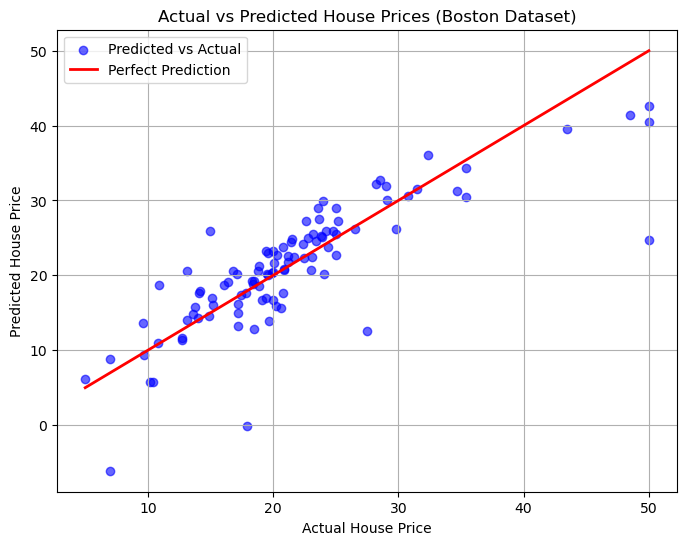

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (Boston Dataset)")
plt.legend()
plt.grid(True)
plt.show()
